                                          Positionnal Encoding

shape of pe: torch.Size([30, 512])


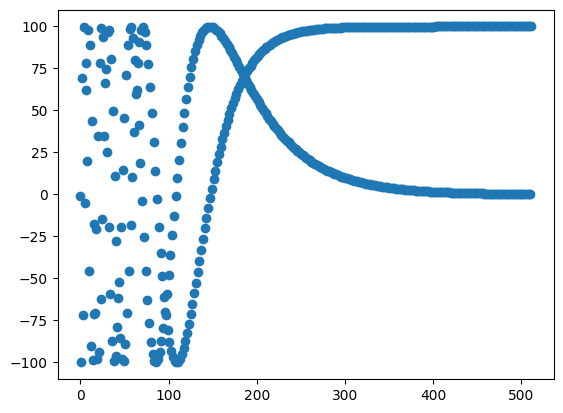

In [8]:
from models import Positionnal_Encoding
import matplotlib.pyplot as plt
import numpy as np

max_len = 30
d_model = 512

pe = Positionnal_Encoding(max_len, d_model)
print(f"shape of pe: {pe.shape}")

idx = np.random.randint(0, max_len)
Y = pe[idx, :].numpy()*100
X = [i for i in range(512)]

plt.plot(X, Y, linestyle='None', marker='o')
plt.show()

This alternation is normal as we have two waves (a sin and a cos)

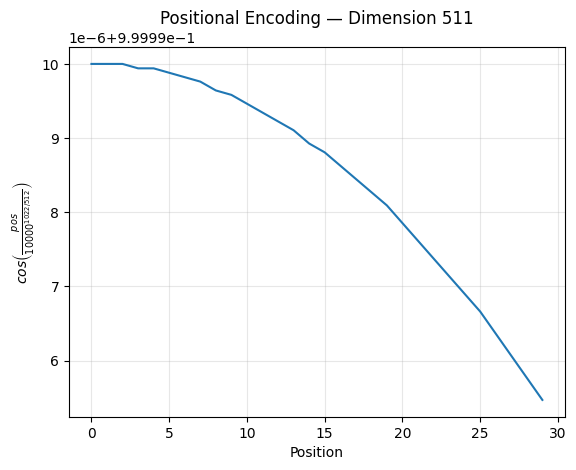

In [9]:
dim = 511

y = pe[:, dim].numpy()
plt.plot(y)

plt.title(f"Positional Encoding — Dimension {dim}")
plt.xlabel("Position")

func = "sin" if dim % 2 == 0 else "cos"
plt.ylabel(rf"${func}\left(\frac{{pos}}{{10000^{{{2*dim}/{d_model}}}}}\right)$")

plt.grid(True, alpha=0.3)
plt.show()


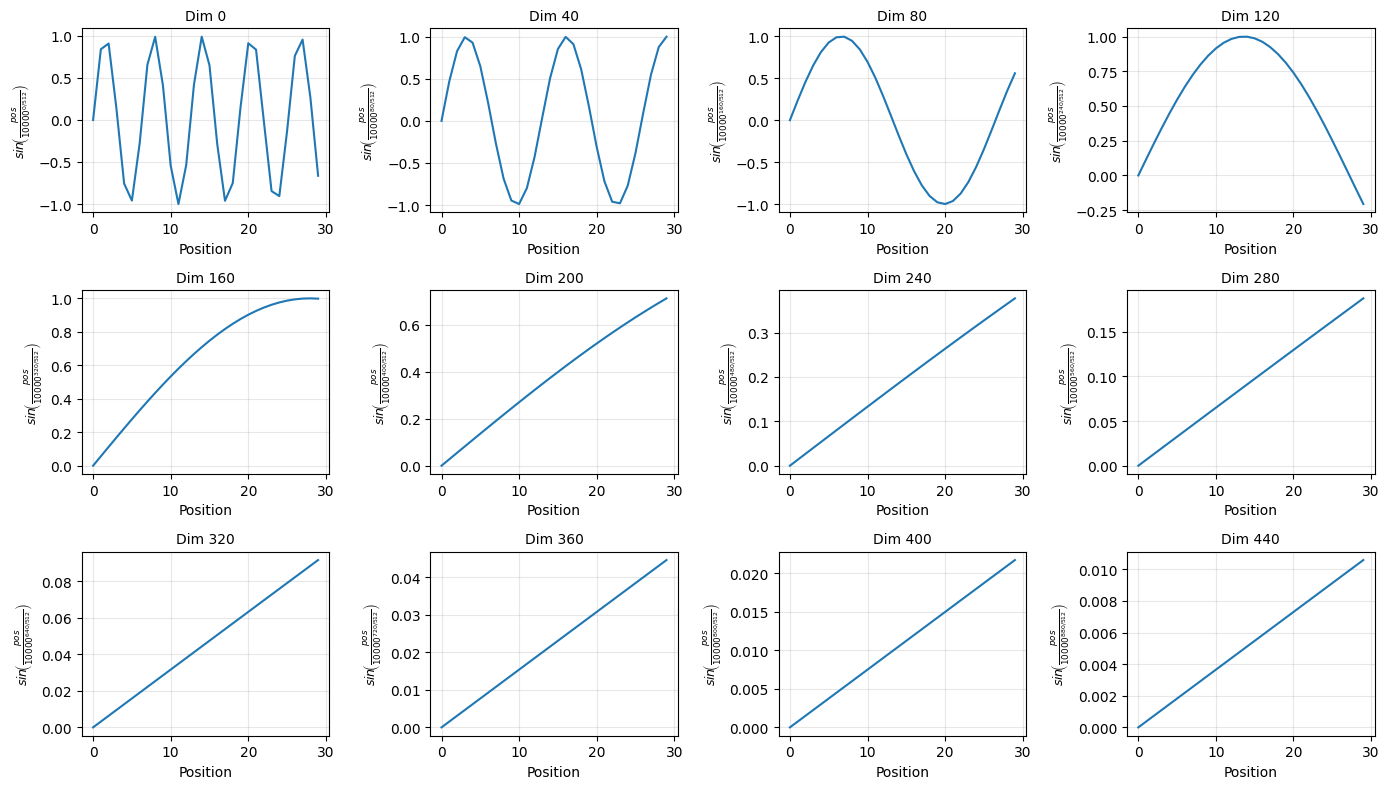

In [10]:
import matplotlib.pyplot as plt

dims = [40 * i for i in range(12)]  # [0, 40, 80, ..., 440]

fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(14, 8))
axes = axes.flatten()

for ax, dim in zip(axes, dims):
    y = pe[:, dim].numpy()
    ax.plot(y)

    ax.set_title(f"Dim {dim}", fontsize=10)
    ax.set_xlabel("Position")

    func = "sin" if dim % 2 == 0 else "cos"
    ax.set_ylabel(
        rf"${func}\!\left(\frac{{pos}}{{10000^{{{2*dim}/{d_model}}}}}\right)$",
        fontsize=9
    )

    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


As we see from these plots the frequency decreases as the dimension increases    

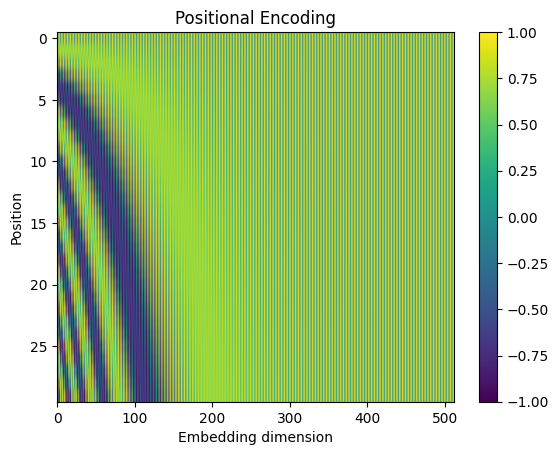

In [11]:
plt.imshow(pe.numpy(), aspect='auto', cmap='viridis')
plt.colorbar()
plt.xlabel("Embedding dimension")
plt.ylabel("Position")
plt.title("Positional Encoding")
plt.show()


In [12]:
# PE(pos,2i)=sin(100002i/dpos​),PE(pos,2i+1)=cos(100002i/dpos​)

                                            Multi-Head-Attention

In [ ]:
import torch.nn as nn
import torch
import math
# this class is for testing, the clean code is in models.py


class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, d_attention, num_heads, dropout):
        super().__init__()
        self.d_attention = d_attention
        self.num_heads = num_heads


        assert d_model == num_heads * d_attention


        self.Q = nn.Linear(d_model, num_heads * d_attention, bias=False)
        self.K = nn.Linear(d_model, num_heads * d_attention, bias=False)
        self.V = nn.Linear(d_model, num_heads * d_attention, bias=False)


        self.out_proj = nn.Linear(num_heads * d_attention, d_model)
        self.attn_dropout = nn.Dropout(dropout)


    # queries shape (Batch_size, q_len, d_model)
    # keys shape (Batch_size, k_len, d_model)
    # values shape (Batch_size, v_len, d_model)
    # pad_mask shape (Batch_size, k_len)
    def forward(self, queries, keys, values, causal_mask=False, pad_mask=None):
        B, q_len, _ = queries.shape
        _, k_len, _ = keys.shape


        Q = self.Q(queries)  # Q shape (Batch_size, q_len, num_heads * d_attention)
        K = self.K(keys)     # K shape (Batch_size, k_len, num_heads * d_attention)
        V = self.V(values)   # V shape (Batch_size, v_len, num_heads * d_attention)

        print(Q.shape)
        print(K.shape)
        print(V.shape)


        Q = Q.reshape(B, q_len, self.num_heads, self.d_attention).transpose(1, 2)
        # Q shape (Batch_size, num_heads, q_len, d_attention)
        K = K.reshape(B, k_len, self.num_heads, self.d_attention).transpose(1, 2)
        # K shape (Batch_size, num_heads, k_len, d_attention)
        V = V.reshape(B, k_len, self.num_heads, self.d_attention).transpose(1, 2)
        # V shape (Batch_size, num_heads, v_len, d_attention)

        print(Q.shape)
        print(K.shape)
        print(V.shape)

        
        
        scores = torch.matmul(Q, K.transpose(2, 3)) / math.sqrt(self.d_attention)
        # scores shape (Batch_size, num_heads, q_len, k_len)
        print(scores.shape)
 

        if pad_mask is not None:
            mask = pad_mask.bool().unsqueeze(1).unsqueeze(1)
            scores = scores.masked_fill(mask, float('-inf'))

        if causal_mask:
            causal = torch.triu(
                torch.ones(q_len, k_len, device=scores.device), diagonal=1
            ).bool()
            scores = scores.masked_fill(causal.unsqueeze(0).unsqueeze(0), float('-inf'))


        attn = torch.softmax(scores, dim=-1) #(Batch_size, num_heads, q_len, k_len)

        attn = self.attn_dropout(attn)


        out = torch.matmul(attn, V)
        out = out.transpose(1, 2).reshape(B, q_len, self.num_heads * self.d_attention)
        print(out.shape)


        return self.out_proj(out)

In [ ]:

d_model = 512
d_attention = 32
num_heads = d_model // d_attention
dropout = 0.3
MHA = MultiHeadAttention(d_model, d_attention, num_heads, dropout)

q_len = 32
k_len = 32
v_len = 32

Batch_size = 64

queries = torch.randn([Batch_size, q_len, d_model])
keys = torch.randn([Batch_size, q_len, d_model])
values = torch.randn([Batch_size, v_len, d_model])

x = MHA.forward(queries, keys, values, causal_mask=True)


torch.Size([64, 32, 512])
torch.Size([64, 32, 512])
torch.Size([64, 32, 512])
torch.Size([64, 16, 32, 32])
torch.Size([64, 16, 32, 32])
torch.Size([64, 16, 32, 32])
torch.Size([64, 16, 32, 32])
torch.Size([64, 32, 512])
False
